#### Libraries + Configuration

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.font_manager as fm
from scipy import stats
from itertools import combinations
import matplotlib
from matplotlib import rcParams

# ── Output directory
OUTPUT_DIR = Path().resolve() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Font settings
matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["axes.unicode_minus"] = False

# ── Global style
rcParams.update({
    "figure.facecolor" : "#1B2A4A",   # Navy background
    "axes.facecolor"   : "#243558",   # Plot area
    "axes.edgecolor"   : "#4A6080",
    "axes.labelcolor"  : "#FFFFFF",   # White
    "axes.titlecolor"  : "#FFFFFF",   # White
    "xtick.color"      : "#FFFFFF",   # White
    "ytick.color"      : "#FFFFFF",   # White
    "text.color"       : "#FFFFFF",   # White
    "grid.color"       : "#4A6080",
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.5,
    "font.size"        : 10,
    "axes.titlesize"   : 12,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 10,
    "legend.framealpha": 0.6,
    "legend.edgecolor" : "#4A6080",
    "legend.facecolor" : "#1B2A4A",
})

# ── Colors
C_GOOD, C_BAD = "#1D9E75", "#C44E52"
C_BEFORE, C_DURING, C_AFTER = "#4C72B0", "#888780", "#C44E52"

# Keep original Korean category values for data processing
TIMING_COLORS = {
    "장전": C_BEFORE,
    "장중": C_DURING,
    "장후": C_AFTER
}

# English labels for visualization
TIMING_LABELS = {
    "장전": "Pre-market",
    "장중": "Intraday",
    "장후": "After-hours"
}

NEWS_LABELS = {
    "호재": "Good News",
    "악재": "Bad News"
}

#### Data Preprocessing

In [2]:
DATA_DIR = Path("../data_collection")

raw_fin  = pd.read_csv(DATA_DIR / "dart_earnings_financials_2019_2026.csv", dtype=str)
raw_ctrl = pd.read_csv(DATA_DIR / "dart_financial_controls_2019_2025.csv")
raw_comp = pd.read_csv(DATA_DIR / "company_krx_fdr_controls_2019_2026.csv")

print(f"Disclosure data: {len(raw_fin):,} rows")

Disclosure data: 16,218 rows


In [3]:
# Filtering
remove = raw_fin["report_nm"].str.contains(
    "전망|기재정정|첨부정정|첨부추가|월별|monthly", na=False, regex=True
)
fin = raw_fin[~remove].copy()
fin["year"] = fin["rcept_dt"].str[:4].astype(int)
fin = fin[fin["year"] <= 2025].copy()

# Remove duplicates, prioritizing consolidated disclosures
fin["is_consolidated"] = fin["report_nm"].str.contains("연결", na=False)
fin = fin.sort_values(
    ["stock_code", "rcept_dt", "is_consolidated", "rcept_no"],
    ascending=[True, True, False, True]
)
fin = fin.drop_duplicates(subset=["stock_code", "rcept_dt"], keep="first")

# Classify disclosure timing
t = fin["rcept_time"].str.split(":", expand=True)
fin["_h"] = pd.to_numeric(t[0], errors="coerce")
fin["_m"] = pd.to_numeric(t[1], errors="coerce")
fin["timing"] = "Intraday"
fin.loc[fin["_h"] < 9, "timing"] = "Pre-market"
fin.loc[(fin["_h"] > 15) | ((fin["_h"] == 15) & (fin["_m"] > 30)), "timing"] = "After-hours"
fin.loc[fin["_h"].isna(), "timing"] = None
fin.drop(columns=["_h", "_m"], inplace=True)
fin["rcept_dt_dt"] = pd.to_datetime(fin["rcept_dt"], format="%Y%m%d")
fin["weekday"] = fin["rcept_dt_dt"].dt.dayofweek

# Classify good and bad news
fin["oi_won"] = pd.to_numeric(fin["operating_income_won"], errors="coerce")
fin = fin.sort_values(["stock_code", "rcept_dt_dt"])
fin["prev_oi"] = fin.groupby("stock_code")["oi_won"].shift(1)
fin["oi_chg_pct"] = np.where(
    fin["prev_oi"].notna() & (fin["prev_oi"] != 0),
    (fin["oi_won"] - fin["prev_oi"]) / fin["prev_oi"].abs(),
    np.nan
)
fin["news"] = np.select(
    [fin["oi_chg_pct"] > 0.10, fin["oi_chg_pct"] < -0.10,
     fin["oi_chg_pct"].between(-0.10, 0.10, inclusive="both")],
    ["Good News", "Bad News", "Neutral"], default="Missing"
)

df = fin.copy()
df_hb = df[df["news"].isin(["Good News", "Bad News"]) & df["timing"].notna()].copy()

print(f"Final sample: {len(df):,} observations")
print(f"Good News: {df['news'].eq('Good News').sum():,}  Bad News: {df['news'].eq('Bad News').sum():,}")
print(f"Timing: {df['timing'].value_counts().to_dict()}")

Final sample: 12,310 observations
Good News: 4,534  Bad News: 4,030
Timing: {'Intraday': 6362, 'After-hours': 5118, 'Pre-market': 811}


### 2-1. Preliminary Setup (Trading Calendar + t=0 Date Assignment)

In [4]:
# ════════════════════════════════════════════════════════════════
# Analysis ②: Event Study
# ════════════════════════════════════════════════════════════════
# Estimation window : t = -120 ~ -21 (100 trading days)
# Event window      : t = -1   ~ +5  (7 trading days)
# t=0 definition    : Intraday disclosure   → Disclosure date
#                     After-hours disclosure → Next trading day
# ════════════════════════════════════════════════════════════════

BG_COLOR = "#1B2A4A"

# ── Load stock price and market index data ─────────────────────
print("Loading stock price data... (this may take some time)")
sp_raw = pd.read_csv(DATA_DIR / "stock_price_2018_2026.csv", low_memory=False)
sp_raw["date"] = pd.to_datetime(sp_raw["date"])
sp_raw["stock_code"] = sp_raw["stock_code"].astype(str).str.zfill(6)

mkt_raw = pd.read_csv(DATA_DIR / "market_index_2018_2026.csv")
mkt_raw["date"] = pd.to_datetime(mkt_raw["date"])

# Separate KOSPI and KOSDAQ indices
kospi_idx = (
    mkt_raw[mkt_raw["index_type"] == "KOSPI"][["date", "change"]]
    .rename(columns={"change": "mkt_ret_kospi"})
)

kosdaq_idx = (
    mkt_raw[mkt_raw["index_type"] == "KOSDAQ"][["date", "change"]]
    .rename(columns={"change": "mkt_ret_kosdaq"})
)

# ── Trading calendar ────────────────────────────────────────────
trading_days = sorted(
    mkt_raw[mkt_raw["index_type"] == "KOSPI"]["date"].unique()
)

td_series = pd.Series(
    range(len(trading_days)),
    index=trading_days
)  # Date → index

print(
    f"Number of trading days: {len(trading_days)} "
    f"({trading_days[0].date()} ~ {trading_days[-1].date()})"
)

def next_trading_day(date):
    """Return the first trading day after the given date."""
    future = [d for d in trading_days if d > date]
    return future[0] if future else None

def get_trading_day_offset(base_date, offset):
    """Return the trading date at the specified offset from base_date."""
    if base_date not in td_series.index:
        return None

    idx = td_series[base_date]
    target_idx = idx + offset

    if 0 <= target_idx < len(trading_days):
        return trading_days[target_idx]

    return None

# ── Assign t=0 event dates ──────────────────────────────────────
# Intraday disclosure    → Disclosure date
# After-hours disclosure → Next trading day
ev = df_hb.copy()
ev["rcept_dt_dt"] = pd.to_datetime(
    ev["rcept_dt"],
    format="%Y%m%d"
)

def set_event_date(row):
    if row["timing"] == "After-hours":
        return next_trading_day(row["rcept_dt_dt"])
    else:
        # Intraday/Pre-market:
        # Use the disclosure date if it is a trading day;
        # otherwise, use the next trading day.
        if row["rcept_dt_dt"] in td_series.index:
            return row["rcept_dt_dt"]

        return next_trading_day(row["rcept_dt_dt"])

ev["event_date"] = ev.apply(set_event_date, axis=1)
ev = ev[ev["event_date"].notna()].copy()

print(f"\nt=0 assignment completed: {len(ev):,} disclosures")
print(
    f"Intraday disclosures with t=0 on the disclosure date: "
    f"{(ev['timing'] == 'Intraday').sum():,}"
)
print(
    f"After-hours disclosures with t=0 on the next trading day: "
    f"{(ev['timing'] == 'After-hours').sum():,}"
)

Loading stock price data... (this may take some time)
Number of trading days: 1923 (2018-07-02 ~ 2026-04-30)

t=0 assignment completed: 8,551 disclosures
Intraday disclosures with t=0 on the disclosure date: 4,354
After-hours disclosures with t=0 on the next trading day: 3,624


### 2-2. Market Model Estimation and CAR Calculation

In [7]:
# ── Stock Return Pivot ─────────────────────────────────────────
print("Creating stock return pivot table...")
sp_pivot = sp_raw.pivot(
    index="date",
    columns="stock_code",
    values="change"
)


# ── CAR Calculation Settings ───────────────────────────────────
EST_START = -120   # Estimation window start
EST_END   = -21    # Estimation window end
EVT_START = -1     # Event window start
EVT_END   = +5     # Event window end


# ── CAR Calculation Function ───────────────────────────────────
def calc_car(stock_code, event_date, market):
    """
    Estimate alpha and beta using the Market Model (OLS)
    and return CAR(-1, +5).

    Returns None if the calculation cannot be completed.
    """
    try:
        # Estimation window dates
        est_dates = [
            get_trading_day_offset(event_date, t)
            for t in range(EST_START, EST_END + 1)
        ]
        est_dates = [d for d in est_dates if d is not None]

        # Event window dates
        evt_dates = [
            get_trading_day_offset(event_date, t)
            for t in range(EVT_START, EVT_END + 1)
        ]
        evt_dates = [d for d in evt_dates if d is not None]

        # Require sufficient trading days
        if len(est_dates) < 60 or len(evt_dates) < 5:
            return None

        # Select market index
        if market == "KOSPI":
            mkt_col = "mkt_ret_kospi"
            mkt_idx = kospi_idx.set_index("date")[mkt_col]

        elif market == "KOSDAQ":
            mkt_col = "mkt_ret_kosdaq"
            mkt_idx = kosdaq_idx.set_index("date")[mkt_col]

        else:
            return None

        # Check whether the stock exists in the return pivot table
        if stock_code not in sp_pivot.columns:
            return None

        stock_ret = sp_pivot[stock_code]

        # ── Estimation Window ───────────────────────────────────
        est_stock = stock_ret.reindex(est_dates)
        est_mkt = mkt_idx.reindex(est_dates)

        # Keep dates where both stock and market returns are available
        est_data = pd.concat(
            [est_stock.rename("stock_ret"),
             est_mkt.rename("market_ret")],
            axis=1
        ).dropna()

        if len(est_data) < 60:
            return None

        # Market Model:
        # stock_ret = alpha + beta * market_ret + error
        X = np.column_stack([
            np.ones(len(est_data)),
            est_data["market_ret"].values
        ])

        y = est_data["stock_ret"].values

        coefficients, *_ = np.linalg.lstsq(
            X,
            y,
            rcond=None
        )

        alpha = coefficients[0]
        beta = coefficients[1]

        # ── Event Window ────────────────────────────────────────
        evt_stock = stock_ret.reindex(evt_dates)
        evt_mkt = mkt_idx.reindex(evt_dates)

        evt_data = pd.concat(
            [evt_stock.rename("stock_ret"),
             evt_mkt.rename("market_ret")],
            axis=1
        )

        # Expected return based on the estimated Market Model
        expected_ret = (
            alpha
            + beta * evt_data["market_ret"]
        )

        # Abnormal Return (AR)
        evt_data["AR"] = (
            evt_data["stock_ret"]
            - expected_ret
        )

        # Require at least 5 valid observations in the event window
        valid_ar = evt_data["AR"].dropna()

        if len(valid_ar) < 5:
            return None

        # Cumulative Abnormal Return (CAR)
        car = valid_ar.sum()

        if np.isnan(car):
            return None

        return car

    except Exception:
        return None


# ── Calculate CAR for All Events ───────────────────────────────
print("Calculating CAR... (may take several minutes)")

cars = []
total = len(ev)

for i, (_, row) in enumerate(ev.iterrows()):

    if i % 500 == 0:
        print(
            f"  Progress: {i:,}/{total:,} "
            f"({i / total * 100:.1f}%)"
        )

    car = calc_car(
        stock_code=str(row["stock_code"]).zfill(6),
        event_date=row["event_date"],
        market=row["market"]
    )

    cars.append(car)


# ── Store CAR Results ───────────────────────────────────────────
ev["CAR"] = cars

ev_clean = (
    ev[ev["CAR"].notna()]
    .copy()
)


# ── Check Category Values ──────────────────────────────────────
print("\nNews categories:")
print(ev_clean["news"].value_counts(dropna=False))

print("\nTiming categories:")
print(ev_clean["timing"].value_counts(dropna=False))


# ── CAR Sample Counts ──────────────────────────────────────────
print(
    f"\nCAR calculation complete: "
    f"{len(ev_clean):,} observations / "
    f"{len(ev):,} total"
)


# Count observations by news type and disclosure timing
group_counts = (
    ev_clean
    .groupby(["news", "timing"])
    .size()
)


# Main four groups used in the analysis
groups = [
    ("Good News", "Intraday"),
    ("Good News", "After-hours"),
    ("Bad News", "Intraday"),
    ("Bad News", "After-hours")
]


for news, timing in groups:
    count = group_counts.get(
        (news, timing),
        0
    )

    print(
        f"  {news} - {timing}: "
        f"{count:,}"
    )


# ── Four-Group Analysis Sample ─────────────────────────────────
analysis_sample = ev_clean[
    ev_clean["news"].isin([
        "Good News",
        "Bad News"
    ])
    &
    ev_clean["timing"].isin([
        "Intraday",
        "After-hours"
    ])
].copy()


print(
    f"\nFour-group analysis sample: "
    f"{len(analysis_sample):,} observations"
)

print(
    f"Excluded from the four-group comparison: "
    f"{len(ev_clean) - len(analysis_sample):,} observations"
)

Creating stock return pivot table...
Calculating CAR... (may take several minutes)
  Progress: 0/8,551 (0.0%)
  Progress: 500/8,551 (5.8%)
  Progress: 1,000/8,551 (11.7%)
  Progress: 1,500/8,551 (17.5%)
  Progress: 2,000/8,551 (23.4%)
  Progress: 2,500/8,551 (29.2%)
  Progress: 3,000/8,551 (35.1%)
  Progress: 3,500/8,551 (40.9%)
  Progress: 4,000/8,551 (46.8%)
  Progress: 4,500/8,551 (52.6%)
  Progress: 5,000/8,551 (58.5%)
  Progress: 5,500/8,551 (64.3%)
  Progress: 6,000/8,551 (70.2%)
  Progress: 6,500/8,551 (76.0%)
  Progress: 7,000/8,551 (81.9%)
  Progress: 7,500/8,551 (87.7%)
  Progress: 8,000/8,551 (93.6%)
  Progress: 8,500/8,551 (99.4%)

News categories:
news
Good News    4517
Bad News     4022
Name: count, dtype: int64

Timing categories:
timing
Intraday       4346
After-hours    3621
Pre-market      572
Name: count, dtype: int64

CAR calculation complete: 8,539 observations / 8,551 total
  Good News - Intraday: 2,454
  Good News - After-hours: 1,734
  Bad News - Intraday: 1,892

### 2-3. CAR Distribution Visualization and Statistical Tests

=== CAR Summary Statistics by Group ===
Good News - Intraday     : Mean 1.78%  Median 0.97%  n=2,454  t=9.43  p=0.0000  *** (p<0.001)
Good News - After-hours  : Mean 1.17%  Median 0.51%  n=1,734  t=5.54  p=0.0000  *** (p<0.001)
Bad News - Intraday      : Mean -1.24%  Median -1.35%  n=1,892  t=-6.67  p=0.0000  *** (p<0.001)
Bad News - After-hours   : Mean -1.75%  Median -1.71%  n=1,887  t=-9.61  p=0.0000  *** (p<0.001)

Bad News - Intraday vs Bad News - After-hours (Mann-Whitney U test)
U=1853130.0,  p=0.042506  * (p<0.05)


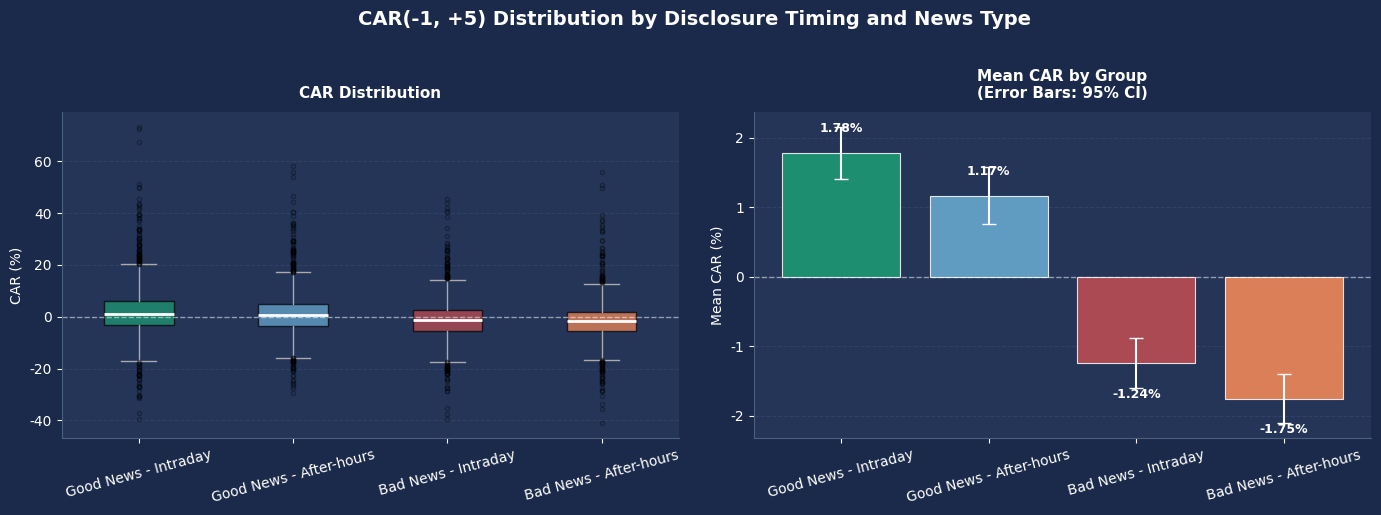

Saved: C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\02_1_car_distribution.png


In [9]:
# ── Significance Label Function ────────────────────────────────
def sig_label(p):
    if p < 0.001:
        return "*** (p<0.001)"
    elif p < 0.01:
        return "** (p<0.01)"
    elif p < 0.05:
        return "* (p<0.05)"
    else:
        return "n.s."


# ── Visualization Settings ─────────────────────────────────────
BG_COLOR = "#1B2A4A"


# ── Define Four Groups ─────────────────────────────────────────
conditions = {
    "Good News - Intraday": ev_clean[
        (ev_clean["news"] == "Good News") &
        (ev_clean["timing"] == "Intraday")
    ]["CAR"],

    "Good News - After-hours": ev_clean[
        (ev_clean["news"] == "Good News") &
        (ev_clean["timing"] == "After-hours")
    ]["CAR"],

    "Bad News - Intraday": ev_clean[
        (ev_clean["news"] == "Bad News") &
        (ev_clean["timing"] == "Intraday")
    ]["CAR"],

    "Bad News - After-hours": ev_clean[
        (ev_clean["news"] == "Bad News") &
        (ev_clean["timing"] == "After-hours")
    ]["CAR"],
}


# ── Summary Statistics ─────────────────────────────────────────
print("=== CAR Summary Statistics by Group ===")

for label, car in conditions.items():
    car_clean = car.dropna()

    t_stat, p_val = stats.ttest_1samp(
        car_clean,
        0
    )

    print(
        f"{label:25s}: "
        f"Mean {car_clean.mean() * 100:.2f}%  "
        f"Median {car_clean.median() * 100:.2f}%  "
        f"n={len(car_clean):,}  "
        f"t={t_stat:.2f}  "
        f"p={p_val:.4f}  "
        f"{sig_label(p_val)}"
    )


# ── Main Comparison: Bad News Intraday vs After-hours ─────────
u_stat, p_mw = stats.mannwhitneyu(
    conditions["Bad News - Intraday"].dropna(),
    conditions["Bad News - After-hours"].dropna(),
    alternative="two-sided"
)

print(
    "\nBad News - Intraday vs Bad News - After-hours "
    "(Mann-Whitney U test)"
)

print(
    f"U={u_stat:.1f},  "
    f"p={p_mw:.6f}  "
    f"{sig_label(p_mw)}"
)


# ── Visualization ──────────────────────────────────────────────
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

fig.patch.set_facecolor(BG_COLOR)

fig.suptitle(
    "CAR(-1, +5) Distribution by Disclosure Timing and News Type",
    fontsize=14,
    fontweight="bold",
    color="#FFFFFF",
    y=1.02
)


# ── Group Colors ───────────────────────────────────────────────
COND_COLORS = {
    "Good News - Intraday": "#1D9E75",
    "Good News - After-hours": "#6BAED6",
    "Bad News - Intraday": "#C44E52",
    "Bad News - After-hours": "#FC8D59",
}


# ── Left Panel: Box Plot ───────────────────────────────────────
ax = axes[0]
ax.set_facecolor("#243558")

bp = ax.boxplot(
    [
        c.dropna() * 100
        for c in conditions.values()
    ],
    tick_labels=list(conditions.keys()),
    patch_artist=True,
    medianprops=dict(
        color="#FFFFFF",
        linewidth=2
    ),
    whiskerprops=dict(
        color="#AAAAAA",
        linewidth=1
    ),
    capprops=dict(
        color="#AAAAAA",
        linewidth=1
    ),
    flierprops=dict(
        marker="o",
        markersize=3,
        alpha=0.3
    )
)

for patch, color in zip(
    bp["boxes"],
    COND_COLORS.values()
):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)


ax.axhline(
    y=0,
    color="#FFFFFF",
    linewidth=1,
    linestyle="--",
    alpha=0.5
)

ax.set_ylabel(
    "CAR (%)",
    fontsize=10
)

ax.set_title(
    "CAR Distribution",
    fontsize=11,
    fontweight="bold",
    pad=10
)

ax.spines[["top", "right"]].set_visible(False)

ax.spines[
    ["left", "bottom"]
].set_color("#4A6080")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
    color="#4A6080"
)

ax.tick_params(
    axis="x",
    rotation=15
)


# ── Right Panel: Mean CAR Bar Chart ────────────────────────────
ax = axes[1]
ax.set_facecolor("#243558")

labels = list(
    conditions.keys()
)

means = [
    c.dropna().mean() * 100
    for c in conditions.values()
]

colors = [
    COND_COLORS[label]
    for label in labels
]

cis = [
    1.96
    * c.dropna().std()
    / np.sqrt(len(c.dropna()))
    * 100
    for c in conditions.values()
]


bars = ax.bar(
    labels,
    means,
    color=colors,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.8,
    zorder=3
)


ax.errorbar(
    labels,
    means,
    yerr=cis,
    fmt="none",
    color="#FFFFFF",
    capsize=5,
    linewidth=1.5,
    zorder=4
)


for bar, mean in zip(
    bars,
    means
):
    offset = (
        0.3
        if mean >= 0
        else -0.5
    )

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        mean + offset,
        f"{mean:.2f}%",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )


ax.axhline(
    y=0,
    color="#FFFFFF",
    linewidth=1,
    linestyle="--",
    alpha=0.5
)

ax.set_ylabel(
    "Mean CAR (%)",
    fontsize=10
)

ax.set_title(
    "Mean CAR by Group\n"
    "(Error Bars: 95% CI)",
    fontsize=11,
    fontweight="bold",
    pad=10
)

ax.spines[["top", "right"]].set_visible(False)

ax.spines[
    ["left", "bottom"]
].set_color("#4A6080")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
    color="#4A6080",
    zorder=1
)

ax.tick_params(
    axis="x",
    rotation=15
)


# ── Save Figure ────────────────────────────────────────────────
plt.tight_layout()

output_path = (
    OUTPUT_DIR
    / "02_1_car_distribution.png"
)

plt.savefig(
    output_path,
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)

plt.show()

print(
    f"Saved: {output_path}"
)

## 2-3. Interpretation of CAR Distribution Comparisons

The analysis shows that the mean CAR was statistically significant across all four disclosure categories (p < 0.001). Overall, good-news disclosures exhibited positive CARs, whereas bad-news disclosures exhibited negative CARs, indicating that the market model used in the event study produced results consistent with the direction of the disclosed information.

| Condition | Mean CAR | Significance |
|---|---:|:---:|
| Good News – Intraday | +1.78% | *** |
| Good News – After-hours | +1.17% | *** |
| Bad News – Intraday | -1.24% | *** |
| Bad News – After-hours | -1.75% | *** |

The key result is the comparison between intraday and after-hours bad-news disclosures.

The mean CAR for after-hours bad-news disclosures was **-1.75%**, approximately **0.51 percentage points lower** than the **-1.24%** observed for intraday bad-news disclosures. The difference between the two groups was also statistically significant (**p = 0.043**).

In other words, bad news disclosed after market hours was associated, on average, with a larger negative market reaction than bad news disclosed during trading hours.

This result is somewhat contrary to the intuition that after-hours disclosure may mitigate short-term stock-price shocks. Instead, after-hours bad-news disclosures were associated with more negative CARs. Two possible explanations can be considered.

First, there may be **selection bias**. Bad news disclosed after hours may contain more severe negative information than bad news disclosed during trading hours. In this case, the observed difference in CARs may be attributable to the severity of the negative information rather than to the timing of disclosure itself.

Second, a **price concentration effect** may exist. Because information released after market close cannot be immediately incorporated into prices through regular trading, the market response may become concentrated at the next trading day's opening or during the early trading session. Under this mechanism, after-hours disclosure could be associated with greater short-term price movements rather than mitigating them.

Regardless of which explanation is more appropriate, the results provide **no evidence that after-hours disclosure serves to mitigate short-term stock-price shocks**.

However, several caveats should be considered when interpreting these findings.

First, the p-value for the difference between intraday and after-hours bad-news disclosures was **0.043**, which is relatively close to the conventional 5% significance threshold. Therefore, the result should be interpreted as **statistically significant but relatively marginal**, rather than as evidence of a strong or highly robust effect.

Second, the current analysis does not control for the **severity of bad news**, measured by the decline in operating profit. Consequently, the comparison may be subject to selection bias. Subsequent regression analysis should therefore re-examine the association between after-hours disclosure and abnormal returns while controlling for bad-news severity and firm-specific characteristics.

### 2-4. Cumulative CAR Trend (t = -1 to +5)

Current values in ev_clean:
news   : <StringArray>
['Good News', 'Bad News']
Length: 2, dtype: str
timing : <StringArray>
['Intraday', 'After-hours', 'Pre-market']
Length: 3, dtype: str

Normalized values:
news   : _news_norm
good    4517
bad     4022
Name: count, dtype: int64
timing : _timing_norm
intraday      4346
afterhours    3621
NaN            572
Name: count, dtype: int64

Calculating daily AR series...

Number of valid AR series:
Good News - Intraday     : n = 2,454
Good News - After-hours  : n = 1,734
Bad News - Intraday      : n = 1,892
Bad News - After-hours   : n = 1,887


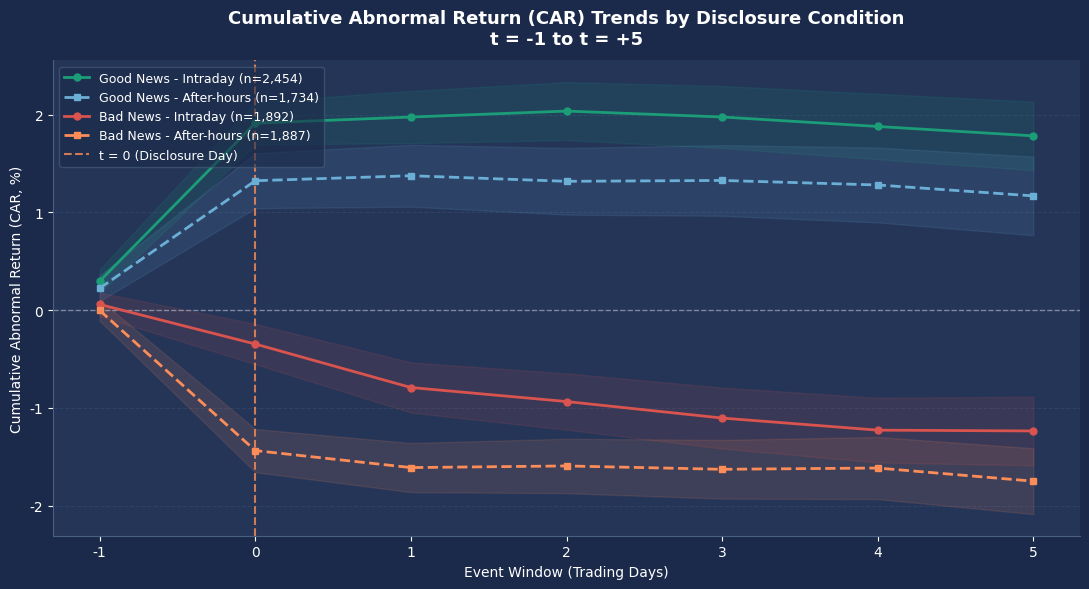

Saved: C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\02_2_car_trend.png


In [14]:
BG_COLOR = "#1B2A4A"

# ============================================================
# Recalculate AR for each event-window day
# ============================================================
def calc_ar_series(stock_code, event_date, market):
    """Return daily AR series over the event window (EVT_START ~ EVT_END)."""
    try:
        est_dates = [
            get_trading_day_offset(event_date, t)
            for t in range(EST_START, EST_END + 1)
        ]
        est_dates = [d for d in est_dates if d is not None]

        evt_dates = [
            get_trading_day_offset(event_date, t)
            for t in range(EVT_START, EVT_END + 1)
        ]
        evt_dates = [d for d in evt_dates if d is not None]

        if len(est_dates) < 60 or len(evt_dates) < 5:
            return None

        mkt_col = (
            "mkt_ret_kospi"
            if market == "KOSPI"
            else "mkt_ret_kosdaq"
        )

        mkt_idx = (
            kospi_idx if market == "KOSPI" else kosdaq_idx
        ).set_index("date")[mkt_col]

        if stock_code not in sp_pivot.columns:
            return None

        stock_ret = sp_pivot[stock_code]

        # Estimation window
        est_stock = stock_ret.reindex(est_dates).dropna()
        est_mkt = mkt_idx.reindex(est_stock.index).dropna()
        est_stock = est_stock.reindex(est_mkt.index)

        if len(est_stock) < 60:
            return None

        # Market Model
        X = np.column_stack([
            np.ones(len(est_mkt)),
            est_mkt.values
        ])

        beta, *_ = np.linalg.lstsq(
            X,
            est_stock.values,
            rcond=None
        )

        alpha, b = beta[0], beta[1]

        # Event-window returns
        evt_stock = stock_ret.reindex(evt_dates).values
        evt_mkt = mkt_idx.reindex(evt_dates).values

        # Abnormal Return
        ar = evt_stock - (alpha + b * evt_mkt)

        return ar

    except Exception:
        return None


# ============================================================
# Event window
# ============================================================
t_range = list(range(EVT_START, EVT_END + 1))


# ============================================================
# Check actual values in the current dataset
# ============================================================
print("Current values in ev_clean:")
print("news   :", ev_clean["news"].dropna().unique())
print("timing :", ev_clean["timing"].dropna().unique())


# ============================================================
# Normalize Korean / English labels
# ============================================================
NEWS_MAP = {
    "호재": "good",
    "Good News": "good",
    "good": "good",
    "GOOD": "good",

    "악재": "bad",
    "Bad News": "bad",
    "bad": "bad",
    "BAD": "bad",
}

TIMING_MAP = {
    "장중": "intraday",
    "Intraday": "intraday",
    "intraday": "intraday",

    "장후": "afterhours",
    "장후 ": "afterhours",
    "After-hours": "afterhours",
    "After Hours": "afterhours",
    "After-hours ": "afterhours",
    "after-hours": "afterhours",
    "afterhours": "afterhours",
}


def normalize_news(value):
    if pd.isna(value):
        return None

    value = str(value).strip()

    return NEWS_MAP.get(value)


def normalize_timing(value):
    if pd.isna(value):
        return None

    value = str(value).strip()

    return TIMING_MAP.get(value)


# Temporary normalized columns
ev_clean = ev_clean.copy()

ev_clean["_news_norm"] = ev_clean["news"].apply(normalize_news)
ev_clean["_timing_norm"] = ev_clean["timing"].apply(normalize_timing)


print("\nNormalized values:")
print("news   :", ev_clean["_news_norm"].value_counts(dropna=False))
print("timing :", ev_clean["_timing_norm"].value_counts(dropna=False))


# ============================================================
# Disclosure conditions
# ============================================================
cond_map = {
    "good_intraday": ("good", "intraday"),
    "good_afterhours": ("good", "afterhours"),
    "bad_intraday": ("bad", "intraday"),
    "bad_afterhours": ("bad", "afterhours"),
}


# ============================================================
# English display labels
# ============================================================
LABEL_EN = {
    "good_intraday": "Good News - Intraday",
    "good_afterhours": "Good News - After-hours",
    "bad_intraday": "Bad News - Intraday",
    "bad_afterhours": "Bad News - After-hours",
}


# ============================================================
# Plot colors
# Same color structure as the original graph
# ============================================================
PLOT_COLORS = {
    "good_intraday": "#1B9E77",
    "good_afterhours": "#6BAED6",
    "bad_intraday": "#D9534F",
    "bad_afterhours": "#FC8D59",
}


# ============================================================
# Calculate daily AR series by condition
# ============================================================
print("\nCalculating daily AR series...")

cond_ar = {key: [] for key in cond_map}


for _, row in ev_clean.iterrows():

    news_norm = row["_news_norm"]
    timing_norm = row["_timing_norm"]

    for label, (news, timing) in cond_map.items():

        if news_norm == news and timing_norm == timing:

            ar_series = calc_ar_series(
                str(row["stock_code"]).zfill(6),
                row["event_date"],
                row["market"]
            )

            if (
                ar_series is not None
                and len(ar_series) == len(t_range)
            ):
                cond_ar[label].append(ar_series)


# ============================================================
# Check sample sizes
# ============================================================
print("\nNumber of valid AR series:")

for label in cond_map:
    print(
        f"{LABEL_EN[label]:25s}: "
        f"n = {len(cond_ar[label]):,}"
    )


# ============================================================
# Plot CAR trends
# ============================================================
fig, ax = plt.subplots(figsize=(11, 6))

fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor("#243558")


for label in cond_map:

    arr = np.array(cond_ar[label])

    if len(arr) == 0:
        print(f"Warning: No observations for {LABEL_EN[label]}")
        continue

    color = PLOT_COLORS[label]

    # Mean daily AR
    mean_ar = np.nanmean(arr, axis=0)

    # Cumulative abnormal return
    cum_ar = np.cumsum(mean_ar) * 100

    # Standard error
    se = (
        np.nanstd(arr, axis=0)
        / np.sqrt(len(arr))
        * 100
    )

    # Approximate cumulative standard error
    cum_se = np.sqrt(np.cumsum(se ** 2))

    # Intraday = solid line + circle
    # After-hours = dashed line + square
    style = "-o" if "intraday" in label else "--s"

    ax.plot(
        t_range,
        cum_ar,
        style,
        color=color,
        linewidth=2,
        markersize=5,
        label=f"{LABEL_EN[label]} (n={len(arr):,})",
        zorder=3
    )

    ax.fill_between(
        t_range,
        cum_ar - 1.96 * cum_se,
        cum_ar + 1.96 * cum_se,
        color=color,
        alpha=0.12,
        zorder=2
    )


# ============================================================
# Reference lines
# ============================================================
ax.axhline(
    y=0,
    color="#FFFFFF",
    linewidth=1,
    linestyle="--",
    alpha=0.4
)

ax.axvline(
    x=0,
    color="#FC8D59",
    linewidth=1.5,
    linestyle="--",
    alpha=0.8,
    label="t = 0 (Disclosure Day)"
)


# ============================================================
# English labels
# ============================================================
ax.set_xlabel(
    "Event Window (Trading Days)",
    fontsize=10
)

ax.set_ylabel(
    "Cumulative Abnormal Return (CAR, %)",
    fontsize=10
)

ax.set_title(
    "Cumulative Abnormal Return (CAR) Trends by Disclosure Condition\n"
    "t = -1 to t = +5",
    fontsize=13,
    fontweight="bold",
    pad=12
)


# ============================================================
# Formatting
# ============================================================
ax.set_xticks(t_range)

ax.legend(
    fontsize=9,
    loc="upper left"
)

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#4A6080")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
    color="#4A6080",
    zorder=1
)


# ============================================================
# Save and display
# ============================================================
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "02_2_car_trend.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)

plt.show()

print(f"Saved: {OUTPUT_DIR / '02_2_car_trend.png'}")

## 2-4. Interpretation of Cumulative CAR Trends

The cumulative abnormal return (CAR) trends show that all four disclosure categories experienced a sharp price reaction around t=0 (the disclosure day). From t=+1 to t=+5, additional price adjustments were relatively gradual, suggesting that a substantial portion of the disclosed information was incorporated into stock prices around the disclosure event.

### Good-News Disclosure Patterns

Good-news disclosures generally exhibited positive CAR trends.

Good News - Intraday showed the largest increase around t=0. The CAR remained positive throughout the subsequent t=+1 to t=+5 period, ultimately remaining at approximately +2%.

Good News - After-hours also exhibited a positive market reaction, but the magnitude was smaller than that of intraday disclosures. The CAR increased to approximately +1.3% around t=0 and remained relatively stable thereafter.

### Bad-News Disclosure Patterns

Bad-news disclosures generally exhibited negative CAR trends.

Bad News - Intraday began to decline around t=0, followed by a gradual additional decrease over the t=+1 to t=+5 period. By the end of the event window, the CAR reached approximately -1.2%.

In contrast, Bad News - After-hours exhibited the strongest negative reaction. The CAR fell sharply to approximately -1.4% around t=0 and declined further over the subsequent event window, ultimately reaching approximately -1.75%.

### Key Observations

The most notable pattern is the sharp and concentrated price reaction to after-hours bad-news disclosures around t=0.

This pattern is consistent with a mechanism in which investors process information released after market close during non-trading hours, with the resulting price adjustment concentrated at the opening or early trading period of the next trading day. Thus, rather than delaying the incorporation of information into prices, after-hours disclosure may be associated with a more concentrated price adjustment.

In contrast, Bad News - Intraday exhibited a more gradual decline following the initial reaction, with additional decreases continuing through approximately t=+1 to t=+3. This pattern suggests that the processing and incorporation of information released during trading hours may be relatively more dispersed over time.

### Overall Interpretation

Overall, after-hours disclosure was associated with a pattern in which price reactions were concentrated around t=0 rather than with an attenuation of short-term stock-price shocks.

Furthermore, the CAR gap between Bad News - Intraday and Bad News - After-hours persisted through t=+5, with no clear evidence of convergence over the event window. This suggests that after-hours bad-news disclosures may be associated with larger negative short-term market reactions.

### Limitations

Several limitations should be considered when interpreting these results.

First, the confidence bands around the cumulative CAR trends are relatively wide, indicating substantial variation across individual disclosure events. Therefore, the average CAR patterns should not be interpreted as applying uniformly to all events.

Second, the current analysis does not control for the severity of bad news, measured by the decline in operating profit. Consequently, it is difficult to distinguish the effect associated with after-hours disclosure itself from differences in the severity of the disclosed information.

Subsequent regression analysis should therefore re-examine the relationship between after-hours disclosure and abnormal returns while controlling for bad-news severity and firm-specific characteristics.